In [1]:
import os
import random


import numpy as np
import torch
from peft import LoraConfig, TaskType, get_peft_model
from torch import nn
from peft import prepare_model_for_kbit_training


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


class ModelForSourceCodeEmbedding(nn.Module):
    def __init__(self, model_name, quantization_config, normalize=True):
        super(ModelForSourceCodeEmbedding, self).__init__()
        model = AutoModel.from_pretrained(model_name, device_map="cuda:0", trust_remote_code=True, quantization_config=quantization_config)
        model = prepare_model_for_kbit_training(model)
        self.model = model
        
        self.normalize = normalize


    def forward(self, **kwargs):
        model_output = self.model(**kwargs)

        embeddings = self.last_token_pool(model_output.last_hidden_state, kwargs['attention_mask'])
        
        if self.normalize:
            embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
        return embeddings


    def last_token_pool(self, last_hidden_states, attention_mask):
        left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
        if left_padding:
            return last_hidden_states[:, -1]
        else:
            sequence_lengths = attention_mask.sum(dim=1) - 1
            batch_size = last_hidden_states.shape[0]
            return last_hidden_states[torch.arange(batch_size, device=last_hidden_states.device), sequence_lengths]


    def __getattr__(self, name: str):
        try:
            return super().__getattr__(name)
        except AttributeError:
            return getattr(self.model, name)

In [2]:
from transformers import BitsAndBytesConfig

config = BitsAndBytesConfig(
    load_in_8bit=True
)

In [3]:
from transformers import AutoModel, AutoTokenizer


model_name = "Qodo/Qodo-Embed-1-1.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name, device_map="cuda:0", trust_remote_code=True)
model = ModelForSourceCodeEmbedding(model_name, config)

model

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

ModelForSourceCodeEmbedding(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151646, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2SdpaAttention(
          (q_proj): Linear8bitLt(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear8bitLt(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear8bitLt(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear8bitLt(in_features=1536, out_features=1536, bias=False)
          (rotary_emb): Qwen2RotaryEmbedding()
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear8bitLt(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear8bitLt(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear8bitLt(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm()
        (post_attention_layernorm): Qwen2RMSNorm()
      )
   

In [4]:
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    bias="none",
    task_type=TaskType.FEATURE_EXTRACTION,
    target_modules=["q_proj", "k_proj", "v_proj"],
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

trainable params: 1,490,944 || all params: 1,544,759,808 || trainable%: 0.09651623458085207


In [5]:
torch.cuda.empty_cache()

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device);

In [7]:
def get_cosing(q1_embs, q2_embs):
    return torch.sum(q1_embs * q2_embs, axis=1)

def get_loss(cosine_score, labels):
    return torch.mean(torch.square(labels * (1 - cosine_score) + torch.clamp((1 - labels) * cosine_score, min=0.0)))

def threshold(x):
    return 1 if x > 0.5 else 0

In [8]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd
from tqdm import tqdm


train_cases = ["case-01", "case-02", "case-03", "case-04", "case-05"]
test_cases = ["case-06", "case-07"]

all_cases = ["case-01", "case-02", "case-03", "case-04", "case-05", "case-06", "case-07"]


def get_data(original_file_path, non_plagiarized_files_paths, plagiarized_files_paths):
    data = []

    for non_plagiarized_file_path in non_plagiarized_files_paths:
        data.append([original_file_path, non_plagiarized_file_path, 0])

    for plagiarized_file_path in plagiarized_files_paths:
        data.append([original_file_path, plagiarized_file_path, 1])

    df = pd.DataFrame(data, columns=["original_code_file", "secondary_code_file", "label"])
    
    return df

def get_paths(case, mode):
    original_file_path = os.path.join("plagiarism_dataset", case, "original", os.listdir(
        f"plagiarism_dataset/{case}/original")[0])

    # get all other cases' files:
    non_plagiarized_files_paths_all = []
    if mode == "train":
        for every_other_case in train_cases:
            if every_other_case != case:
                non_plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join("plagiarism_dataset", every_other_case)) for f in filenames if os.path.splitext(f)[1] == '.java']
                non_plagiarized_files_paths_all += non_plagiarized_files_paths
    else:
        for every_other_case in all_cases:
            if every_other_case != case:
                non_plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join("plagiarism_dataset", every_other_case)) for f in filenames if os.path.splitext(f)[1] == '.java']
                non_plagiarized_files_paths_all += non_plagiarized_files_paths

    # add your own case non-plagiarised files:
    non_plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join(
        "plagiarism_dataset", case, "non-plagiarized")) for f in filenames if os.path.splitext(f)[1] == '.java']
    non_plagiarized_files_paths_all += non_plagiarized_files_paths

    plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join(
        "plagiarism_dataset", case, "plagiarized")) for f in filenames if os.path.splitext(f)[1] == '.java']

    return original_file_path, non_plagiarized_files_paths_all, plagiarized_files_paths

In [9]:
original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths("case-01", "train")
print("Original")
print(original_file_path)
print("Non-plagiarized")
print(non_plagiarized_files_paths)
print("Plagiarized")
print(plagiarized_files_paths)

Original
plagiarism_dataset\case-01\original\T1.java
Non-plagiarized
['plagiarism_dataset\\case-02\\non-plagiarized\\01\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\02\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\03\\Nomor2_2451041557A22145B3701B0184109CAB013.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\04\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\05\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\06\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\07\\Main.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\08\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\09\\t02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\10\\Main.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\11\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\12\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\13\\No2.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\14\\Soal2.java', 'plagiarism_dataset

In [10]:
original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths("case-06", "test")
print("Original")
print(original_file_path)
print("Non-plagiarized")
print(non_plagiarized_files_paths)
print("Plagiarized")
print(plagiarized_files_paths)

Original
plagiarism_dataset\case-06\original\T6.java
Non-plagiarized
['plagiarism_dataset\\case-01\\non-plagiarized\\01\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\02\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\03\\Nomor1_2451041557A22145B3701B0184109CAB013.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\04\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\05\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\06\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\07\\Main.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\08\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\09\\t01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\10\\Main.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\11\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\12\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\13\\No1.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\14\\Soal1.java', 'plagiarism_dataset

In [11]:
# train-test cycle:
EPOCHS = 30

epochs_losses_train = []
epochs_accuracies_train = []

epochs_losses_test = []
epochs_accuracies_test = []

for epoch in range(EPOCHS):
    train_total_loss = 0
    train_correct = 0
    
    test_total_loss = 0
    test_correct = 0
    
    # train:
    for case in train_cases:
        original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths(case, "train")
        train_df = get_data(original_file_path, non_plagiarized_files_paths, plagiarized_files_paths)
        train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
        X_train, y_train = train_df[["original_code_file", "secondary_code_file"]], train_df["label"]
    
        ros = RandomOverSampler(random_state=42)
        X_train, y_train = ros.fit_resample(X_train, y_train)
        
        X_train = X_train.reset_index(drop=True)
        y_train = y_train.reset_index(drop=True)
    
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
        loss = nn.CrossEntropyLoss()
        
        total_loss = 0
        correct = 0
        
        model.train()
        bar = tqdm(range(len(X_train)))
        for i in range(len(X_train)):
            original_code = open(X_train["original_code_file"][i], "r").read()
            secondary_code = open(X_train["secondary_code_file"][i], "r").read()
            
            q1 = tokenizer(original_code, max_length=32000, padding=True, truncation=True, return_tensors='pt')
            q2 = tokenizer(secondary_code, max_length=32000, padding=True, truncation=True, return_tensors='pt')
            
            q1 = {k: v.to(device) for k, v in q1.items()} # move to GPU
            q2 = {k: v.to(device) for k, v in q2.items()} # move to GPU
            
            label = torch.tensor([y_train[i]])
            label = label.to(device)
            
            optimizer.zero_grad()
            q1 = model(**q1)
            q2 = model(**q2)
            loss_value = get_loss(get_cosing(q1, q2).to(device), label)
            total_loss += loss_value.item()
            loss_value.backward()
            optimizer.step()
        
            prediction = threshold(get_cosing(q1, q2).item())
            if prediction == label:
                correct += 1
            bar.update(1)
        
        train_total_loss += total_loss / len(X_train)
        train_correct += correct / len(X_train)

    # test:
    for case in test_cases:
        original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths(case, "test")
        test_df = get_data(original_file_path, non_plagiarized_files_paths, plagiarized_files_paths)
        test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)
        X_test, y_test = test_df[["original_code_file", "secondary_code_file"]], test_df["label"]
    
        total_loss = 0
        correct = 0
        
        model.eval()
        bar = tqdm(range(len(X_test)))
        for i in range(len(X_test)):
            original_code = open(X_test["original_code_file"][i], "r").read()
            secondary_code = open(X_test["secondary_code_file"][i], "r").read()

            q1 = tokenizer(original_code, max_length=32000, padding=True, truncation=True, return_tensors='pt')
            q2 = tokenizer(secondary_code, max_length=32000, padding=True, truncation=True, return_tensors='pt')
            
            q1 = {k: v.to(device) for k, v in q1.items()}
            q2 = {k: v.to(device) for k, v in q2.items()}
            
            label = torch.tensor([y_test[i]])
            label = label.to(device)
            
            q1 = model(**q1)
            q2 = model(**q2)
            loss_value = get_loss(get_cosing(q1, q2).to(device), label)
            total_loss += loss_value.item()
            
            prediction = threshold(get_cosing(q1, q2).item())
            if prediction == label:
                correct += 1
            bar.update(1)
        
        test_total_loss += total_loss / len(X_test)
        test_correct += correct / len(X_test)
    
    epochs_losses_train.append(train_total_loss / 5)
    print(f"Epoch: {epoch}, Loss train: {train_total_loss / 5}")
    epochs_accuracies_train.append(train_correct / 5)
    print(f"Epoch: {epoch}, Accuracy train: {train_correct / 5}")
    
    epochs_losses_test.append(test_total_loss / 2)
    print(f"Epoch: {epoch}, Loss test: {test_total_loss / 2}")
    epochs_accuracies_test.append(test_correct / 2)
    print(f"Epoch: {epoch}, Accuracy test: {test_correct / 2}")

    torch.save(model, f"models_sfr_embedding/{epoch + 1}_emb_model.pth")

  0%|          | 0/584 [00:00<?, ?it/s]`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
C:\Users\bred7\anaconda3\envs\vyatsu_environment\Lib\site-packages\torch\utils\checkpoint.py:464: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.4 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
C:\Users\bred7\anaconda3\envs\vyatsu_environment\Lib\site-packages\bitsandbytes\autograd\_functions.py:316: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
C:\Users\bred7\.cache\huggingface\modules\transformers_modules\Qodo\Qodo-Embed-

Epoch: 0, Loss train: 0.041781883984712144
Epoch: 0, Accuracy train: 0.9405942621699623
Epoch: 0, Loss test: 0.060044647559836545
Epoch: 0, Accuracy test: 0.9066523605150214


AttributeError: Can't pickle local object 'PreTrainedModel.enable_input_require_grads.<locals>.make_inputs_require_grads'

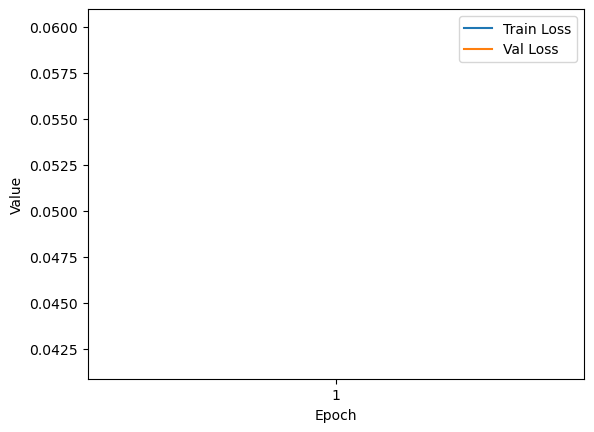

In [20]:
import matplotlib.pyplot as plt
EPOCHS = 1
plt.plot(range(1, EPOCHS + 1), epochs_losses_train, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), epochs_losses_test, label="Val Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.xticks(range(1, EPOCHS + 1))

plt.show()

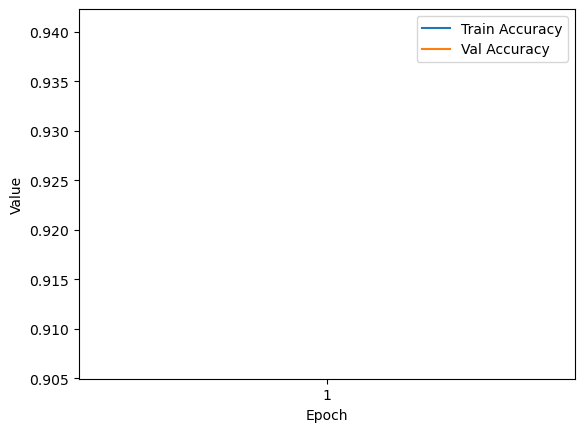

In [21]:
plt.plot(range(1, EPOCHS + 1), epochs_accuracies_train, label="Train Accuracy")
plt.plot(range(1, EPOCHS + 1), epochs_accuracies_test, label="Val Accuracy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.xticks(range(1, EPOCHS + 1))

plt.show()

In [22]:
# torch.save(model, "models_codebert/code_embedding_model.pth")

In [23]:
# model = torch.load("code_embedding_model.pth")
# model.eval()

In [24]:
epochs_losses_test, len(epochs_losses_test)

([0.060044647559836545], 1)

In [25]:
epochs_accuracies_test, len(epochs_accuracies_test)

([0.9066523605150214], 1)

In [26]:
print(f"Max accuracy: {max(epochs_accuracies_test)} at epoch {epochs_accuracies_test.index(max(epochs_accuracies_test)) + 1}")
print(f"Min loss: {min(epochs_losses_test)} at epoch {epochs_losses_test.index(min(epochs_losses_test)) + 1}")

Max accuracy: 0.9066523605150214 at epoch 1
Min loss: 0.060044647559836545 at epoch 1
